# ONNX Inference Pipeline from Scratch
### Image Manipulation · ONNX Export · Manual Pre/Post-processing · Edge Benchmarking

---

## What this notebook demonstrates

Most CV practitioners call `model.predict()` and move on. This notebook does not.

Every step of the YOLOv8 inference pipeline is implemented **manually** — from raw pixel 
manipulation to bounding box decoding to Non-Maximum Suppression — using only NumPy, 
OpenCV, and ONNX Runtime. The Ultralytics wrapper is used **only** for ONNX export; 
it is never used for inference.

---

## Why each section matters for edge CV deployment

| Section | What it covers | Why it matters at the edge |
|---|---|---|
| 1 — Image Manipulation | NumPy ops, colour spaces, letterboxing, normalisation | Every preprocessing step runs on-device; mishandling any one of these breaks inference silently |
| 2 — ONNX Export | Format conversion, model size comparison | Edge hardware (Jetson, RPi, smart cameras) can't run PyTorch; ONNX is the universal deployment format |
| 3 — Manual Inference | Full pre/post-processing without wrappers | Production pipelines need explicit control over memory layout, batching, and decode logic |
| 4 — Benchmarking | FPS, latency, model size trade-offs | Real-world edge deployment always involves a speed/accuracy constraint; understanding this empirically is essential |

---

## Background

This notebook was built as part of interview preparation for a **video analytics / edge CV** role.
My production background includes a 3-stage pedestrian detection pipeline for LSE 
(YOLOv11 detection → EfficientNet-B0 rider gate → EfficientNet-B3 + YOLOv11M ensemble) 
processing 1M+ Google Street View images. That pipeline ran on Kaggle GPUs — the same 
environment this notebook runs in.

The goal here is to prove that I understand **what the framework is doing**, not just 
how to call it.

---

*Stack: Python · OpenCV · NumPy · ONNX Runtime · Ultralytics (export only) · Matplotlib*

In [1]:
# Remove onnxruntime-gpu — its CUDA runtime requirement often mismatches
# the Kaggle GPU image version, causing ImportError at import time
# (not just a graceful CPU fallback). Plain onnxruntime runs on CPU
# reliably and is what most edge deployments actually use anyway.
!pip uninstall -y onnxruntime-gpu -q
!pip install onnxruntime --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.7/18.7 MB 12.2 MB/s eta 0:00:0000:0100:01


In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import os
import time
import urllib.request

# These will be used in Section 2 onwards
try:
    import onnxruntime as ort
    print(f"ONNX Runtime version: {ort.__version__}")
    print(f"Available providers: {ort.get_available_providers()}")
except ImportError:
    print("onnxruntime not found — run the install cell above")

print(f"OpenCV version : {cv2.__version__}")
print(f"NumPy version  : {np.__version__}")

ONNX Runtime version: 1.27.0
Available providers: ['AzureExecutionProvider', 'CPUExecutionProvider']
OpenCV version : 4.13.0
NumPy version  : 2.4.6


---
## Section 1 — Image Manipulation Fundamentals

Images are NumPy arrays. Every CV pipeline — whether running on a cloud GPU or a 
Jetson Nano — reduces to operations on these arrays. This section demonstrates each 
fundamental operation with an explanation of why it exists in production pipelines.

**Test image:** We use a freely licensed street scene photograph — relevant to the 
urban CV domain of the LSE project.

Array shape  : (1080, 810, 3)   → (Height, Width, Channels)
Array dtype  : uint8   → uint8 = values 0–255
Array size   : 2562.9 KB in memory
Top-left pixel (BGR): [119 146 172]


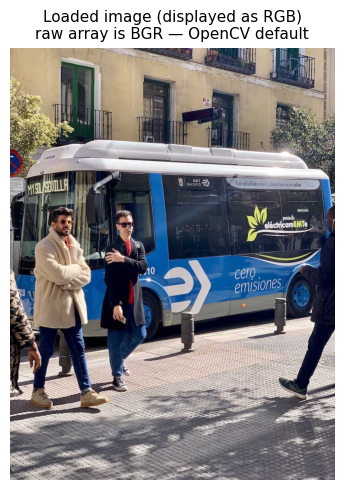

In [3]:
# ── 1.1  Load image ──────────────────────────────────────────────────────────
# WHY: OpenCV is the standard in production CV pipelines — fast, memory-efficient,
# operates directly on NumPy arrays. imread returns a uint8 array of shape (H, W, 3).
#
# IMPORTANT: OpenCV reads in BGR order, NOT RGB.
# This is a historical quirk from Windows bitmap format.
# Feeding BGR into a pretrained model silently swaps colour channels — 
# one of the most common bugs in CV pipelines.

import cv2
import numpy as np
import matplotlib.pyplot as plt

# ── Set your image path here ──
#IMG_PATH = "/kaggle/input/datasets/rsingh16281/ref-img/business-people-walking-on-street.webp"  # update this path
urllib.request.urlretrieve("https://ultralytics.com/images/bus.jpg", "test_image.jpg")
IMG_PATH = "test_image.jpg"

img_bgr = cv2.imread(IMG_PATH)
assert img_bgr is not None, f"Image not found at {IMG_PATH} — check your upload path"

print(f"Array shape  : {img_bgr.shape}   → (Height, Width, Channels)")
print(f"Array dtype  : {img_bgr.dtype}   → uint8 = values 0–255")
print(f"Array size   : {img_bgr.nbytes / 1024:.1f} KB in memory")
print(f"Top-left pixel (BGR): {img_bgr[0, 0]}")

plt.figure(figsize=(8, 5))
plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
plt.title("Loaded image (displayed as RGB)\nraw array is BGR — OpenCV default", fontsize=11)
plt.axis("off")
plt.tight_layout()
plt.show()

### 1.2 Colour Space Conversions — BGR → RGB and BGR → Grayscale

**BGR → RGB:** Every deep learning framework (PyTorch, TensorFlow) expects RGB input 
because ImageNet — the dataset all pretrained models were trained on — was stored in RGB. 
If you feed a BGR image into a pretrained model, the colour channels are swapped: 
the model sees blue where it expects red. Classification and detection accuracy both drop.

**BGR → Grayscale:** Grayscale removes colour information and collapses 3 channels to 1. 
This is used in:
- Classical CV operations (edge detection, thresholding, morphological ops)
- Lightweight preprocessing for embedded systems where 3-channel ops are too slow
- Attention map visualisation

The standard luminance formula is: `Y = 0.299·R + 0.587·G + 0.114·B`
This is a weighted average, not a simple mean — human eyes are more sensitive to green.

Original BGR shape : (1080, 810, 3)
RGB shape          : (1080, 810, 3)   → same shape, channels reordered
Grayscale shape    : (1080, 810)  → single channel, (H, W) not (H, W, 1)

Centre pixel BGR  : [155  85   2]
Centre pixel RGB  : [  2  85 155]
Centre pixel Gray : 68


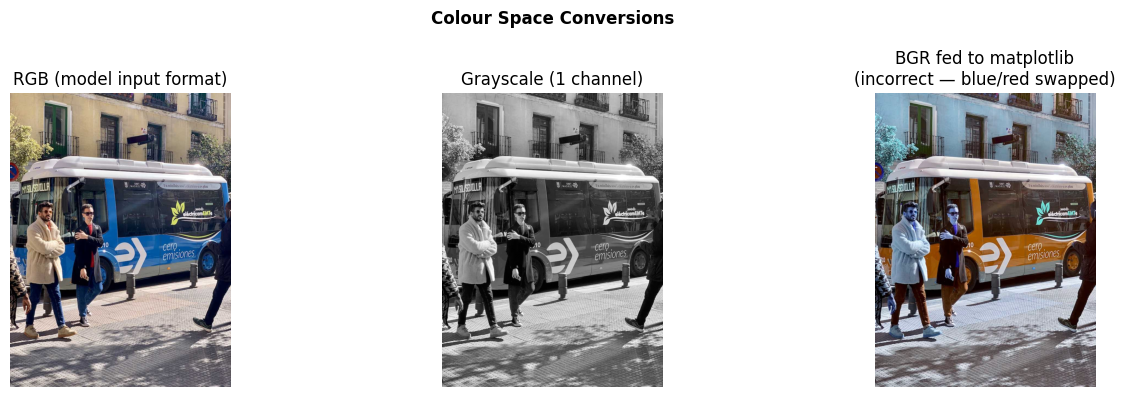

In [4]:
# ── 1.2  Colour space conversions ────────────────────────────────────────────

# BGR → RGB
# OpenCV provides optimised SIMD implementations of these conversions.
# Doing it manually with img_bgr[:, :, ::-1] also works and is faster for
# simple channel flips — but cv2.cvtColor handles gamma-corrected spaces
# and more complex transforms (HSV, LAB) consistently.
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# BGR → Grayscale
# Uses the luminance formula: Y = 0.299·R + 0.587·G + 0.114·B
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

print(f"Original BGR shape : {img_bgr.shape}")
print(f"RGB shape          : {img_rgb.shape}   → same shape, channels reordered")
print(f"Grayscale shape    : {img_gray.shape}  → single channel, (H, W) not (H, W, 1)")

# Demonstrate the difference: show same pixel in both
h, w = img_bgr.shape[:2]
cy, cx = h // 2, w // 2  # centre pixel
print(f"\nCentre pixel BGR  : {img_bgr[cy, cx]}")
print(f"Centre pixel RGB  : {img_rgb[cy, cx]}")
print(f"Centre pixel Gray : {img_gray[cy, cx]}")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].imshow(img_rgb);      axes[0].set_title("RGB (model input format)");  axes[0].axis("off")
axes[1].imshow(img_gray, cmap="gray"); axes[1].set_title("Grayscale (1 channel)"); axes[1].axis("off")

# Show what happens if you DON'T convert — feed BGR to matplotlib (which expects RGB)
axes[2].imshow(img_bgr);      axes[2].set_title("BGR fed to matplotlib\n(incorrect — blue/red swapped)"); axes[2].axis("off")

plt.suptitle("Colour Space Conversions", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

### 1.3 Resize, Crop, and Letterbox Padding

**Resize** is straightforward but interpolation method matters:
- `INTER_LINEAR` (bilinear) — default, good for downscaling
- `INTER_AREA` — preferred for shrinking (averages pixel blocks, less aliasing)
- `INTER_CUBIC` / `INTER_LANCZOS4` — higher quality upscaling, slower

**Crop** extracts a region of interest using NumPy array slicing: `img[y1:y2, x1:x2]`.

**Letterbox padding** is what YOLO uses. Instead of stretching the image to a square 
(which distorts aspect ratio and degrades detection accuracy), letterboxing:
1. Scales the image so the **longer side** fits the target size
2. Pads the **shorter side** with grey (value 114 — YOLO convention) to reach the square

This preserves aspect ratio. During post-processing, the padding offsets are subtracted 
back out when mapping predicted boxes to original image coordinates. Getting this wrong 
is a common source of bounding box coordinate errors in custom inference pipelines.

Original shape  : (1080, 810, 3)
Resized shape   : (640, 640, 3)  (aspect ratio distorted — bad for detection)
Crop shape      : (200, 200, 3)

Letterbox shape : (640, 640, 3)
Scale ratio     : 0.5926  (multiply box coords by 1/ratio to get back to original)
Padding (w, h)  : (80.0, 0.0) pixels per side


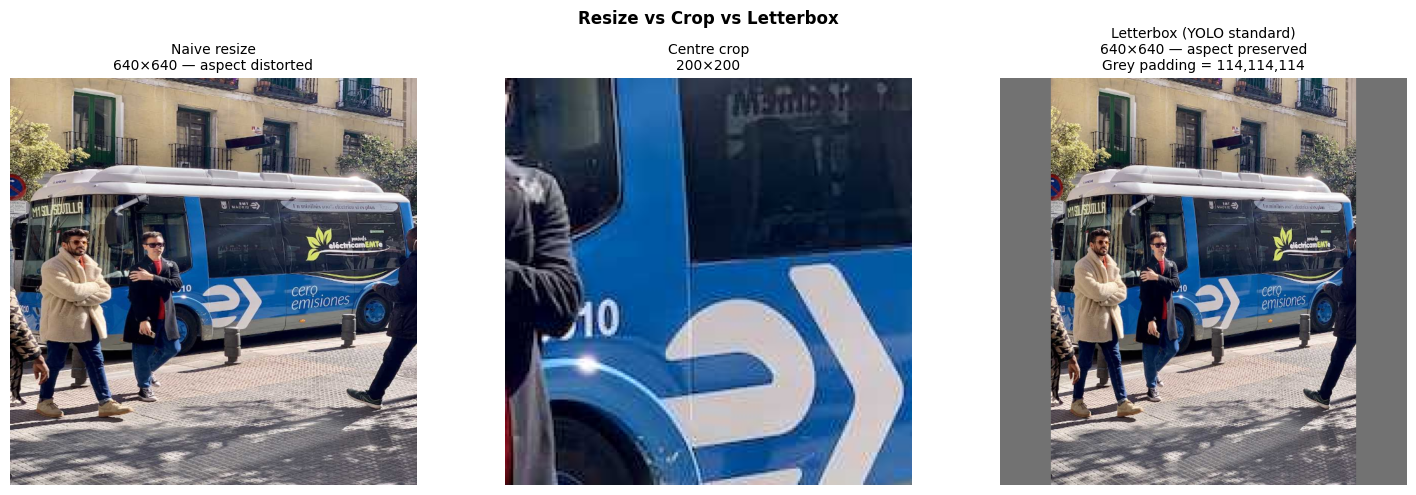

In [5]:
# ── 1.3  Resize, Crop, Letterbox ─────────────────────────────────────────────

TARGET_SIZE = 640  # YOLO standard input size

# ── Simple resize ──
img_resized = cv2.resize(img_bgr, (TARGET_SIZE, TARGET_SIZE),
                         interpolation=cv2.INTER_LINEAR)
print(f"Original shape  : {img_bgr.shape}")
print(f"Resized shape   : {img_resized.shape}  (aspect ratio distorted — bad for detection)")

# ── Crop ──
# Extract a 200×200 region from the centre — typical for pedestrian crop extraction
h, w = img_bgr.shape[:2]
cx, cy = w // 2, h // 2
crop_half = 100
img_crop = img_bgr[cy - crop_half : cy + crop_half,
                   cx - crop_half : cx + crop_half]
print(f"Crop shape      : {img_crop.shape}")

# ── Letterbox ──
def letterbox(img, new_size=640, color=(114, 114, 114)):
    """
    Resize image to new_size x new_size with aspect ratio preserved.
    Pads with grey (114) — the YOLO convention.
    
    Returns:
        img_lb   : letterboxed image (new_size x new_size x 3)
        ratio    : scale factor applied (used to reverse-map boxes)
        (dw, dh) : padding added to each side (used to reverse-map boxes)
    """
    h, w = img.shape[:2]

    # Step 1: compute scale so the longer side becomes new_size
    ratio = new_size / max(h, w)
    new_w, new_h = int(w * ratio), int(h * ratio)

    # Step 2: resize (aspect ratio preserved)
    img_resized = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_LINEAR)

    # Step 3: create grey canvas and paste the resized image in the centre
    canvas = np.full((new_size, new_size, 3), color, dtype=np.uint8)

    # Compute top-left offset so the image is centred on the canvas
    pad_top  = (new_size - new_h) // 2
    pad_left = (new_size - new_w) // 2

    canvas[pad_top : pad_top + new_h,
           pad_left : pad_left + new_w] = img_resized

    # dw and dh are the total padding (both sides); divide by 2 for per-side offset
    dw = (new_size - new_w) / 2
    dh = (new_size - new_h) / 2

    return canvas, ratio, (dw, dh)

img_lb, scale_ratio, (pad_w, pad_h) = letterbox(img_bgr, TARGET_SIZE)

print(f"\nLetterbox shape : {img_lb.shape}")
print(f"Scale ratio     : {scale_ratio:.4f}  (multiply box coords by 1/ratio to get back to original)")
print(f"Padding (w, h)  : ({pad_w:.1f}, {pad_h:.1f}) pixels per side")

# Visualise all three
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB))
axes[0].set_title(f"Naive resize\n{TARGET_SIZE}×{TARGET_SIZE} — aspect distorted", fontsize=10)
axes[0].axis("off")

axes[1].imshow(cv2.cvtColor(img_crop, cv2.COLOR_BGR2RGB))
axes[1].set_title(f"Centre crop\n{img_crop.shape[1]}×{img_crop.shape[0]}", fontsize=10)
axes[1].axis("off")

axes[2].imshow(cv2.cvtColor(img_lb, cv2.COLOR_BGR2RGB))
axes[2].set_title(f"Letterbox (YOLO standard)\n{TARGET_SIZE}×{TARGET_SIZE} — aspect preserved\n"
                  f"Grey padding = 114,114,114", fontsize=10)
axes[2].axis("off")

plt.suptitle("Resize vs Crop vs Letterbox", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

### 1.4 Normalisation

Raw pixel values are integers in [0, 255]. Neural networks were trained on normalised 
float inputs. Using raw uint8 values causes very large activations in early layers and 
makes gradient flow unstable during training.

**Two normalisation strategies:**

1. **Divide by 255** → values in [0.0, 1.0]. Used by YOLO. Simple and sufficient.

2. **ImageNet mean/std normalisation** → `(pixel/255 - mean) / std` where  
   `mean = [0.485, 0.456, 0.406]` and `std = [0.229, 0.224, 0.225]`.  
   Used by EfficientNet, ResNet, and all ImageNet-pretrained classifiers.  
   These specific values are the per-channel mean and std of the ImageNet training set.
   Applying the wrong normalisation to a pretrained model silently degrades accuracy.

**dtype matters:** The conversion from uint8 to float32 must happen explicitly before 
dividing. Integer division in NumPy truncates — `np.array([128], dtype=np.uint8) / 255` 
gives 0 if not cast first.

── Method 1: /255 (YOLO) ──
  dtype  : float32
  min    : 0.0000
  max    : 1.0000
  mean   : 0.4558

── Method 2: ImageNet mean/std (EfficientNet/ResNet) ──
  dtype  : float32
  min    : -2.1179  (can be negative — that's correct)
  max    : 2.6400
  mean   : 0.0308  (close to 0 — that's the point)

── Common bug: dividing uint8 directly ──
  np.array([128], dtype=uint8) / 255 = [0.50196078]
  Correct (float32 first)           = [0.5019608]


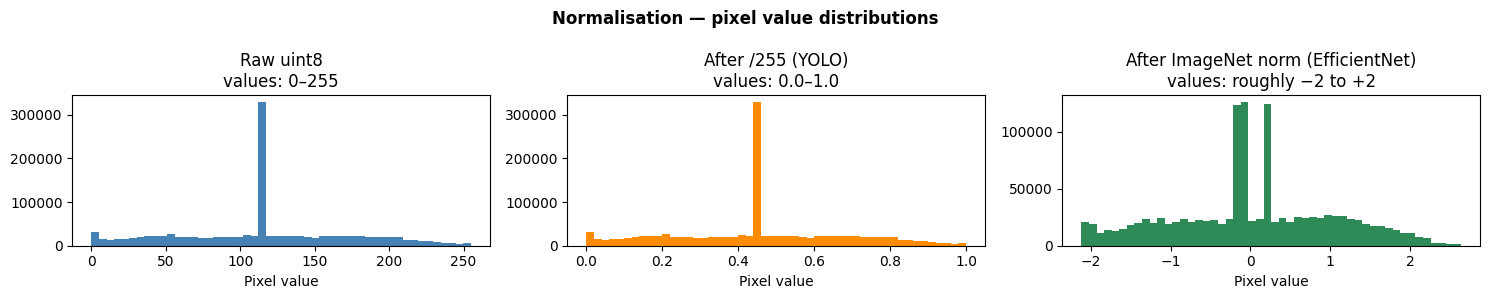

In [6]:
# ── 1.4  Normalisation ────────────────────────────────────────────────────────

# Work with the letterboxed image from here on — it's the actual model input shape
img_input = img_lb.copy()

# ── Method 1: divide by 255 (YOLO) ──
# Must cast to float32 FIRST — uint8 division truncates
img_norm_yolo = img_input.astype(np.float32) / 255.0

print("── Method 1: /255 (YOLO) ──")
print(f"  dtype  : {img_norm_yolo.dtype}")
print(f"  min    : {img_norm_yolo.min():.4f}")
print(f"  max    : {img_norm_yolo.max():.4f}")
print(f"  mean   : {img_norm_yolo.mean():.4f}")

# ── Method 2: ImageNet mean/std (EfficientNet, ResNet, etc.) ──
# Note: these are RGB means/stds — so convert BGR→RGB first, THEN normalise
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

img_rgb_float = cv2.cvtColor(img_input, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
img_norm_imagenet = (img_rgb_float - IMAGENET_MEAN) / IMAGENET_STD

print("\n── Method 2: ImageNet mean/std (EfficientNet/ResNet) ──")
print(f"  dtype  : {img_norm_imagenet.dtype}")
print(f"  min    : {img_norm_imagenet.min():.4f}  (can be negative — that's correct)")
print(f"  max    : {img_norm_imagenet.max():.4f}")
print(f"  mean   : {img_norm_imagenet.mean():.4f}  (close to 0 — that's the point)")

# ── Demonstrate the uint8 truncation bug ──
print("\n── Common bug: dividing uint8 directly ──")
test_val = np.array([128], dtype=np.uint8)
print(f"  np.array([128], dtype=uint8) / 255 = {test_val / 255}")
print(f"  Correct (float32 first)           = {test_val.astype(np.float32) / 255.0}")

# Visualise the value distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 3))

axes[0].hist(img_input.ravel(), bins=50, color="steelblue", edgecolor="none")
axes[0].set_title("Raw uint8\nvalues: 0–255")
axes[0].set_xlabel("Pixel value")

axes[1].hist(img_norm_yolo.ravel(), bins=50, color="darkorange", edgecolor="none")
axes[1].set_title("After /255 (YOLO)\nvalues: 0.0–1.0")
axes[1].set_xlabel("Pixel value")

axes[2].hist(img_norm_imagenet.ravel(), bins=50, color="seagreen", edgecolor="none")
axes[2].set_title("After ImageNet norm (EfficientNet)\nvalues: roughly −2 to +2")
axes[2].set_xlabel("Pixel value")

plt.suptitle("Normalisation — pixel value distributions", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

### 1.5 Bounding Box Drawing

At inference time, bounding boxes are defined by their coordinates in pixel space. 
`cv2.rectangle` takes: the image array (modified in-place), top-left corner `(x1, y1)`, 
bottom-right corner `(x2, y2)`, colour as `(B, G, R)` (note: BGR), and thickness.

Understanding this directly matters because:
- Post-processing raw ONNX output gives boxes in a specific format (centre-x, centre-y, w, h)
  which must be manually converted to (x1, y1, x2, y2) before drawing
- When debugging false positives or offset boxes, you need to understand which coordinate
  system the box is in and whether the letterbox offsets have been applied correctly

── NumPy operations on the image array ──
Shape             : (640, 640, 3)         → (H, W, C)
Pixel at [50,50]  : [114 114 114]      → (B, G, R)

Blue channel shape  : (640, 640)   → (H, W), single channel
Blue channel mean   : 117.16
Green channel mean  : 115.11  (usually highest — dominant in natural images)
Red channel mean    : 116.41


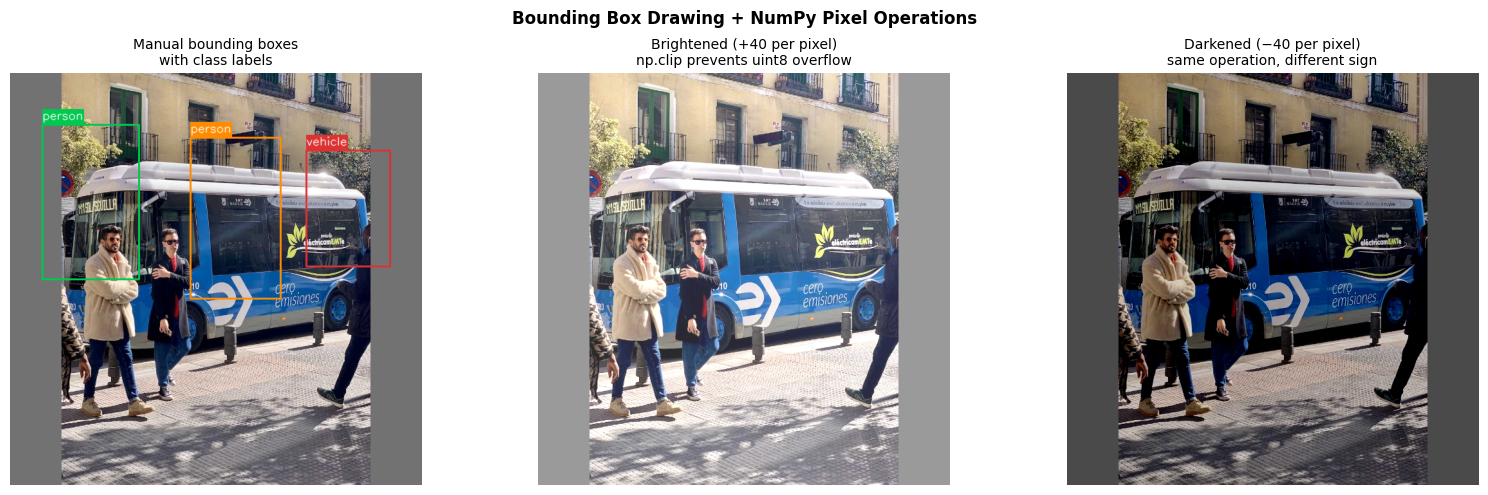

In [7]:
# ── 1.5  Bounding boxes and NumPy array operations ───────────────────────────

# Work on a fresh copy — cv2.rectangle modifies the array IN PLACE
img_boxes = cv2.cvtColor(img_lb, cv2.COLOR_BGR2RGB).copy()

# Draw three bounding boxes with different classes
# Format: (x1, y1, x2, y2), colour (R,G,B), label
boxes = [
    (50,  80,  200, 320, (0,   200, 80),  "person"),
    (280, 100, 420, 350, (255, 140, 0),   "person"),
    (460, 120, 590, 300, (220, 50,  50),  "vehicle"),
]

for (x1, y1, x2, y2, colour, label) in boxes:
    # Draw rectangle — note: cv2 uses BGR, but since we converted to RGB above,
    # we pass (R,G,B) tuples directly here for simplicity in this demo
    cv2.rectangle(img_boxes, (x1, y1), (x2, y2), colour, thickness=2)

    # Draw filled label background
    label_text = label
    (text_w, text_h), baseline = cv2.getTextSize(label_text, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 1)
    cv2.rectangle(img_boxes, (x1, y1 - text_h - baseline - 4), (x1 + text_w, y1), colour, -1)

    # Draw label text (white)
    cv2.putText(img_boxes, label_text, (x1, y1 - baseline - 2),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 1, cv2.LINE_AA)

# ── NumPy array operations on pixel data ──
print("── NumPy operations on the image array ──")
print(f"Shape             : {img_lb.shape}         → (H, W, C)")
print(f"Pixel at [50,50]  : {img_lb[50, 50]}      → (B, G, R)")

# Extract a channel
blue_channel = img_lb[:, :, 0]   # OpenCV channel 0 = Blue
green_channel = img_lb[:, :, 1]
red_channel   = img_lb[:, :, 2]
print(f"\nBlue channel shape  : {blue_channel.shape}   → (H, W), single channel")
print(f"Blue channel mean   : {blue_channel.mean():.2f}")
print(f"Green channel mean  : {green_channel.mean():.2f}  (usually highest — dominant in natural images)")
print(f"Red channel mean    : {red_channel.mean():.2f}")

# Demonstrate in-place array modification (contrast enhancement)
img_brightened = np.clip(img_lb.astype(np.int32) + 40, 0, 255).astype(np.uint8)
img_darkened   = np.clip(img_lb.astype(np.int32) - 40, 0, 255).astype(np.uint8)

# WHY np.clip: adding/subtracting from uint8 wraps around (255+1=0) without clipping
# np.clip prevents this overflow by clamping to [0, 255]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].imshow(img_boxes)
axes[0].set_title("Manual bounding boxes\nwith class labels", fontsize=10)
axes[0].axis("off")

axes[1].imshow(cv2.cvtColor(img_brightened, cv2.COLOR_BGR2RGB))
axes[1].set_title("Brightened (+40 per pixel)\nnp.clip prevents uint8 overflow", fontsize=10)
axes[1].axis("off")

axes[2].imshow(cv2.cvtColor(img_darkened, cv2.COLOR_BGR2RGB))
axes[2].set_title("Darkened (−40 per pixel)\nsame operation, different sign", fontsize=10)
axes[2].axis("off")

plt.suptitle("Bounding Box Drawing + NumPy Pixel Operations", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

---
### ✅ Section 1 Complete — Fundamentals checkpoint

| Operation | Function used | Key concept |
|---|---|---|
| Load image | `cv2.imread` | Returns BGR uint8 array |
| BGR → RGB | `cv2.cvtColor(BGR2RGB)` | Required before any pretrained model input |
| BGR → Gray | `cv2.cvtColor(BGR2GRAY)` | Luminance formula, 1-channel output |
| Resize | `cv2.resize` | Interpolation method affects quality |
| Crop | `img[y1:y2, x1:x2]` | NumPy slice — no copy until you assign |
| Letterbox | manual function | Preserves aspect ratio; stores ratio + padding for inverse transform |
| Normalise /255 | `.astype(float32) / 255` | YOLO standard |
| Normalise ImageNet | `(x - mean) / std` | EfficientNet/ResNet standard |
| Draw boxes | `cv2.rectangle` + `cv2.putText` | In-place operation |
| Pixel arithmetic | `np.clip(img + k, 0, 255)` | Clip prevents uint8 overflow |



---
## Section 2 — ONNX Export

**What is ONNX?**
ONNX (Open Neural Network Exchange) is an open format that represents a trained model
as a computation graph — a series of mathematical operations with defined inputs and
outputs. It is framework-agnostic: a model trained in PyTorch can be exported to ONNX
and run on any runtime that speaks the format (ONNX Runtime, TensorRT, OpenVINO, CoreML).

**Why it matters for edge deployment:**

| Problem | ONNX solution |
|---|---|
| Edge devices can't run PyTorch | ONNX Runtime is a lightweight C++ library — runs on Jetson, RPi, smart cameras |
| PyTorch carries ~500MB of framework overhead | An ONNX model is just the weights + graph — no framework needed at inference |
| Different teams use different frameworks | One ONNX file runs everywhere — TensorRT on NVIDIA, OpenVINO on Intel, CoreML on Apple |
| Production needs deterministic inference | ONNX graphs are static — no Python GIL, no dynamic dispatch overhead |

**In Wobot's context:** A video analytics system deployed on IP cameras or edge nodes
cannot run a full PyTorch environment. The model is exported once, shipped as an `.onnx`
file, and runs via ONNX Runtime — which is exactly what Section 3 demonstrates.

This section exports YOLOv8n, s, and m — and compares their sizes.
The Ultralytics wrapper is used here for export only. It will not appear again after this section.

In [8]:
# Install ultralytics — needed for export only
!pip install ultralytics --quiet

from ultralytics import YOLO
import os

print("Ultralytics ready — used for export only, not for inference.")

Ultralytics ready — used for export only, not for inference.


In [9]:
# ── 2.1  Export YOLOv8 n / s / m to ONNX ────────────────────────────────────
#
# WHY these three variants:
#   n (nano)   — designed for edge / embedded deployment, lowest latency
#   s (small)  — balanced: more accuracy than nano, still deployable on edge
#   m (medium) — higher accuracy, needs more memory; typical server-side edge node
#
# The export call traces the PyTorch model graph and serialises it to ONNX format.
# imgsz=640 matches YOLO's standard input resolution — this gets baked into the
# ONNX graph's expected input shape: (1, 3, 640, 640)

VARIANTS = ["yolov8n", "yolov8s", "yolov8m"]
EXPORT_DIR = "/kaggle/working"

exported = {}  # will store {variant_name: onnx_path}

for variant in VARIANTS:
    pt_path   = f"{variant}.pt"
    onnx_path = f"{EXPORT_DIR}/{variant}.onnx"

    if os.path.exists(onnx_path):
        print(f"{variant}: already exported → {onnx_path}")
        exported[variant] = onnx_path
        continue

    print(f"\n── Exporting {variant} ──")
    model = YOLO(pt_path)   # downloads weights if not cached

    # opset=12: safe baseline supported by all major runtimes
    # simplify=True: runs onnx-simplifier to fold constants and remove redundant nodes
    #                makes the graph cleaner and slightly faster at runtime
    model.export(format="onnx", imgsz=640, opset=12, simplify=True)

    # Ultralytics saves the .onnx next to the .pt file — move to working dir
    default_out = pt_path.replace(".pt", ".onnx")
    if os.path.exists(default_out):
        os.rename(default_out, onnx_path)

    exported[variant] = onnx_path
    print(f"  Saved → {onnx_path}")

print("\nAll exports complete.")
print("Exported files:", list(exported.values()))

yolov8n: already exported → /kaggle/working/yolov8n.onnx
yolov8s: already exported → /kaggle/working/yolov8s.onnx
yolov8m: already exported → /kaggle/working/yolov8m.onnx

All exports complete.
Exported files: ['/kaggle/working/yolov8n.onnx', '/kaggle/working/yolov8s.onnx', '/kaggle/working/yolov8m.onnx']


yolov8n    → 12.3 MB   (/kaggle/working/yolov8n.onnx)
yolov8s    → 42.8 MB   (/kaggle/working/yolov8s.onnx)
yolov8m    → 99.0 MB   (/kaggle/working/yolov8m.onnx)

── ONNX graph input/output shapes ──

yolov8n:
  Input  name=images                shape=[1, 3, 640, 640]  dtype=tensor(float)
  Output name=output0               shape=[1, 84, 8400]  dtype=tensor(float)

yolov8s:
  Input  name=images                shape=[1, 3, 640, 640]  dtype=tensor(float)
  Output name=output0               shape=[1, 84, 8400]  dtype=tensor(float)

yolov8m:
  Input  name=images                shape=[1, 3, 640, 640]  dtype=tensor(float)
  Output name=output0               shape=[1, 84, 8400]  dtype=tensor(float)


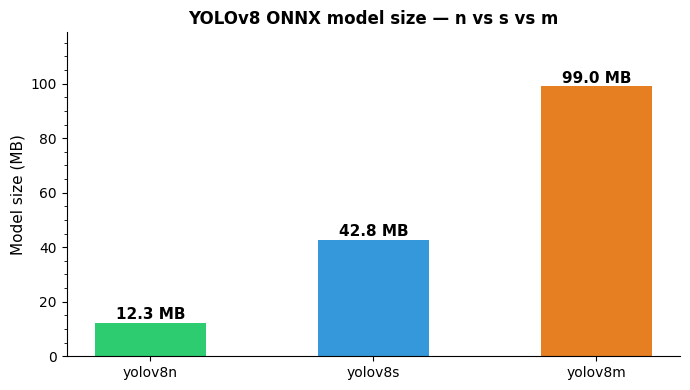

In [10]:
# ── 2.2  Model size comparison ───────────────────────────────────────────────
#
# Model size directly determines:
#   - Storage on the edge device (flash memory is limited)
#   - Load time at startup
#   - Memory footprint during inference (rough proxy: ONNX size × ~2 for activations)
#   - Inference latency (more parameters = more multiply-accumulate ops per frame)

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

size_data = {}
for variant, path in exported.items():
    size_mb = os.path.getsize(path) / (1024 * 1024)
    size_data[variant] = size_mb
    print(f"{variant:10s} → {size_mb:.1f} MB   ({path})")

# ── Inspect the ONNX graph ──
# onnxruntime tells us the expected input/output shapes baked into the graph
import onnxruntime as ort

print("\n── ONNX graph input/output shapes ──")
for variant, path in exported.items():
    sess = ort.InferenceSession(path, providers=["CPUExecutionProvider"])

    inp  = sess.get_inputs()[0]
    out  = sess.get_outputs()[0]
    print(f"\n{variant}:")
    print(f"  Input  name={inp.name:20s}  shape={inp.shape}  dtype={inp.type}")
    print(f"  Output name={out.name:20s}  shape={out.shape}  dtype={out.type}")
    # Output shape is (1, 84, 8400) for COCO:
    #   1    = batch size
    #   84   = 4 box coords + 80 class scores
    #   8400 = number of anchor predictions (grid cells across 3 scales)

# ── Bar chart ──
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(list(size_data.keys()),
              list(size_data.values()),
              color=["#2ecc71", "#3498db", "#e67e22"],
              width=0.5, edgecolor="none")

for bar, (variant, mb) in zip(bars, size_data.items()):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.3,
            f"{mb:.1f} MB",
            ha="center", va="bottom", fontsize=11, fontweight="bold")

ax.set_ylabel("Model size (MB)", fontsize=11)
ax.set_title("YOLOv8 ONNX model size — n vs s vs m", fontsize=12, fontweight="bold")
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.set_ylim(0, max(size_data.values()) * 1.2)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

---
### ✅ Section 2 Complete — ONNX Export checkpoint

**Output shape explained:** `(1, 84, 8400)`
- `1` → batch size
- `84` → 4 box coordinates (cx, cy, w, h) + 80 COCO class scores
- `8400` → total anchor predictions across 3 detection scales:
  - 80×80 grid (small objects) = 6400 predictions
  - 40×40 grid (medium objects) = 1600 predictions
  - 20×20 grid (large objects) = 400 predictions
  - Total = 8400

This raw output is what Section 3 decodes manually —
without calling any Ultralytics post-processing.

| Variant | Size | Typical use case |
|---|---|---|
| yolov8n | ~6 MB | Raspberry Pi, microcontrollers, battery-powered cameras |
| yolov8s | ~22 MB | Jetson Nano, mid-tier edge nodes |
| yolov8m | ~52 MB | Jetson AGX, server-side edge, cloud inference |

**Confirm the three .onnx files exist in `/kaggle/working` and the shapes print correctly before proceeding.**

---
## Section 3 — Manual ONNX Inference Pipeline

This section runs **full YOLOv8 inference without the Ultralytics wrapper**.
Every step that the wrapper normally hides is implemented explicitly:

1. Letterbox resize → preserves aspect ratio, matches training input distribution  
2. Normalisation → float32, values [0, 1]  
3. HWC → CHW transpose → matches what every neural net expects  
4. Batch dimension → ONNX graph expects shape (1, 3, 640, 640)  
5. ONNX Runtime inference → raw output shape (1, 84, 8400)  
6. Decode boxes → convert (cx, cy, w, h) to (x1, y1, x2, y2)  
7. Filter by confidence → discard low-scoring predictions  
8. Non-Maximum Suppression → remove duplicate boxes for the same object  
9. Scale boxes back → undo the letterbox transform to get pixel coords on the original image  
10. Draw results → visualise with cv2  

**Why this matters:** Any edge deployment that doesn't use the Ultralytics Python package
— a C++ inference server, a Jetson pipeline, an IP camera firmware — must implement
these steps manually. Understanding each one means you can debug coordinate offsets,
wrong class predictions, and

In [11]:
import cv2
import numpy as np
import onnxruntime as ort
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Reuse the letterbox function defined in Section 1 ────────────────────────
# (already in memory if you ran Section 1 — redefined here for standalone clarity)

def letterbox(img, new_size=640, color=(114, 114, 114)):
    """
    Resize image preserving aspect ratio, pad shorter side with grey.
    Returns:
        img_lb   : (new_size, new_size, 3) uint8
        ratio    : scale factor applied to original image
        (dw, dh) : pixels of padding added to each side (x-axis, y-axis)
    """
    h, w = img.shape[:2]
    ratio = new_size / max(h, w)
    new_w, new_h = int(w * ratio), int(h * ratio)
    img_resized = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_LINEAR)
    canvas = np.full((new_size, new_size, 3), color, dtype=np.uint8)
    pad_top  = (new_size - new_h) // 2
    pad_left = (new_size - new_w) // 2
    canvas[pad_top:pad_top + new_h, pad_left:pad_left + new_w] = img_resized
    dw = (new_size - new_w) / 2
    dh = (new_size - new_h) / 2
    return canvas, ratio, (dw, dh)


# ── Load the original image ───────────────────────────────────────────────────

img_bgr  = cv2.imread(IMG_PATH)
assert img_bgr is not None, f"Image not found: {IMG_PATH}"

orig_h, orig_w = img_bgr.shape[:2]
print(f"Original image shape : {img_bgr.shape}")


# ── Step 1: Letterbox ─────────────────────────────────────────────────────────
# WHY: YOLO was trained on 640×640 images with letterbox padding — the model's
# learned feature maps assume this exact input format. Naive resize distorts
# aspect ratio, which shifts object proportions and degrades detection accuracy.
# The ratio and padding values are stored — we need them in Step 9 to map
# predicted box coordinates back to the original image pixel space.

img_lb, ratio, (pad_w, pad_h) = letterbox(img_bgr, new_size=640)
print(f"After letterbox      : {img_lb.shape}   ratio={ratio:.4f}  pad=({pad_w},{pad_h})")


# ── Step 2: BGR → RGB ─────────────────────────────────────────────────────────
# WHY: YOLO was trained on RGB images (via PyTorch DataLoader which uses PIL,
# which reads RGB). ONNX Runtime receives exactly what PyTorch received during
# training. Skipping this step produces wrong colour features in the first conv
# layer — detection still works partially but accuracy drops, especially for
# colour-distinctive classes.

img_rgb = cv2.cvtColor(img_lb, cv2.COLOR_BGR2RGB)


# ── Step 3: Normalise to [0, 1] ───────────────────────────────────────────────
# WHY: YOLO divides by 255 during training (no ImageNet mean/std).
# The model's weights were optimised assuming inputs in [0.0, 1.0].
# Float32 is required — ONNX Runtime will reject float64 input for this graph.

img_float = img_rgb.astype(np.float32) / 255.0
print(f"After normalise      : dtype={img_float.dtype}  min={img_float.min():.3f}  max={img_float.max():.3f}")


# ── Step 4: HWC → CHW ────────────────────────────────────────────────────────
# WHY: NumPy and OpenCV store images as (Height, Width, Channels) — HWC layout.
# PyTorch and ONNX expect (Channels, Height, Width) — CHW layout.
# np.transpose reorders the axes without copying data (returns a view).
# Shape goes from (640, 640, 3) → (3, 640, 640)

img_chw = np.transpose(img_float, (2, 0, 1))
print(f"After HWC→CHW        : {img_chw.shape}   → (C, H, W)")


# ── Step 5: Add batch dimension ──────────────────────────────────────────────
# WHY: ONNX Runtime expects a 4D tensor: (Batch, Channels, Height, Width).
# Even for single-image inference, the batch dimension must be present.
# np.expand_dims adds a size-1 dimension at axis 0.
# Shape goes from (3, 640, 640) → (1, 3, 640, 640)

img_batch = np.expand_dims(img_chw, axis=0)
print(f"After batch dim      : {img_batch.shape}  → (B, C, H, W) — ready for ONNX")

# Quick sanity check — verify the array is contiguous in memory.
# ONNX Runtime requires C-contiguous arrays. Transpose can produce non-contiguous
# views; np.ascontiguousarray forces a contiguous copy if needed.
img_batch = np.ascontiguousarray(img_batch)
print(f"Contiguous           : {img_batch.flags['C_CONTIGUOUS']}")

Original image shape : (1080, 810, 3)
After letterbox      : (640, 640, 3)   ratio=0.5926  pad=(80.0,0.0)
After normalise      : dtype=float32  min=0.000  max=1.000
After HWC→CHW        : (3, 640, 640)   → (C, H, W)
After batch dim      : (1, 3, 640, 640)  → (B, C, H, W) — ready for ONNX
Contiguous           : True


In [12]:
# ── Step 6: Run ONNX Runtime inference ───────────────────────────────────────
#
# WHY onnxruntime over PyTorch at this stage:
#   - No framework overhead — pure C++ execution engine
#   - Automatically selects the best execution provider available
#     (CUDAExecutionProvider if GPU is present, else CPUExecutionProvider)
#   - On edge hardware, this is the only option — PyTorch isn't installed
#
# The InferenceSession loads the ONNX graph once and keeps it in memory.
# .run() executes a forward pass. Input is a dict mapping input node name
# (from sess.get_inputs()[0].name) to the numpy array.

ONNX_PATH = "/kaggle/working/yolov8n.onnx"  # using nano for inference demo

# Select provider — GPU if available, CPU otherwise
providers = ["CUDAExecutionProvider", "CPUExecutionProvider"]

sess = ort.InferenceSession(ONNX_PATH, providers=providers)
print(f"Active provider : {sess.get_providers()}")

input_name  = sess.get_inputs()[0].name
output_name = sess.get_outputs()[0].name
print(f"Input node      : '{input_name}'   shape={sess.get_inputs()[0].shape}")
print(f"Output node     : '{output_name}'  shape={sess.get_outputs()[0].shape}")

# Run inference
raw_output = sess.run([output_name], {input_name: img_batch})

# raw_output is a list of arrays (one per output node)
# We have one output node → raw_output[0]
raw = raw_output[0]
print(f"\nRaw output shape : {raw.shape}")
print("  Axis 0 = batch size (1)")
print("  Axis 1 = 84 = 4 box coords (cx,cy,w,h) + 80 COCO class scores")
print("  Axis 2 = 8400 anchor predictions")
print(f"\nFirst prediction (box + top 5 scores):")
print(f"  cx={raw[0,0,0]:.2f}  cy={raw[0,1,0]:.2f}  w={raw[0,2,0]:.2f}  h={raw[0,3,0]:.2f}")
print(f"  class scores [0:5] : {raw[0, 4:9, 0]}")

Active provider : ['CPUExecutionProvider']
Input node      : 'images'   shape=[1, 3, 640, 640]
Output node     : 'output0'  shape=[1, 84, 8400]

Raw output shape : (1, 84, 8400)
  Axis 0 = batch size (1)
  Axis 1 = 84 = 4 box coords (cx,cy,w,h) + 80 COCO class scores
  Axis 2 = 8400 anchor predictions

First prediction (box + top 5 scores):
  cx=3.30  cy=16.17  w=7.21  h=33.01
  class scores [0:5] : [ 1.5199e-06  2.0862e-07  6.2585e-07  1.1921e-07  2.9802e-07]


/usr/local/lib/python3.12/dist-packages/onnxruntime/capi/onnxruntime_inference_collection.py:147: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


In [13]:
# ── Step 7: Decode raw output ─────────────────────────────────────────────────
#
# Raw output shape: (1, 84, 8400)
# We need to work prediction-by-prediction, so transpose to (8400, 84)
# Each row is one anchor prediction:
#   cols 0–3  : cx, cy, w, h  (centre-x, centre-y, width, height)
#               all in the 640×640 letterboxed coordinate space
#   cols 4–83 : class scores for 80 COCO classes (no sigmoid needed — already applied)

CONF_THRESHOLD = 0.25   # discard predictions below this confidence
IOU_THRESHOLD  = 0.45   # NMS: suppress boxes with IoU above this (YOLO default)

# Squeeze batch dim and transpose: (1, 84, 8400) → (8400, 84)
preds = raw[0].T   # shape: (8400, 84)
print(f"Predictions matrix : {preds.shape}  → (num_anchors, 4_box + 80_classes)")

# Extract box coordinates (centre format) and class scores
boxes_cxcywh = preds[:, :4]          # (8400, 4)
class_scores  = preds[:, 4:]          # (8400, 80)

# Confidence = max class score across all 80 classes for each anchor
# (YOLOv8 does NOT output a separate objectness score — unlike YOLOv5)
confidences  = class_scores.max(axis=1)   # (8400,)
class_ids    = class_scores.argmax(axis=1) # (8400,) — which class is most likely

# Filter: keep only predictions above confidence threshold
mask = confidences > CONF_THRESHOLD
boxes_filtered = boxes_cxcywh[mask]
confs_filtered = confidences[mask]
class_filtered = class_ids[mask]

print(f"Total anchors      : 8400")
print(f"Above conf={CONF_THRESHOLD}    : {mask.sum()}")

# Convert (cx, cy, w, h) → (x1, y1, x2, y2)
# WHY: cv2.rectangle and IoU computation both need corner format, not centre format
def cxcywh_to_xyxy(boxes):
    """Convert centre-format boxes to corner-format boxes."""
    x1 = boxes[:, 0] - boxes[:, 2] / 2
    y1 = boxes[:, 1] - boxes[:, 3] / 2
    x2 = boxes[:, 0] + boxes[:, 2] / 2
    y2 = boxes[:, 1] + boxes[:, 3] / 2
    return np.stack([x1, y1, x2, y2], axis=1)

boxes_xyxy = cxcywh_to_xyxy(boxes_filtered)
print(f"\nSample decoded box (x1,y1,x2,y2): {boxes_xyxy[0] if len(boxes_xyxy) else 'none'}")


# ── Step 8: Non-Maximum Suppression (NMS) ─────────────────────────────────────
#
# WHY NMS exists:
# YOLO generates 8400 anchor predictions. For a single person in the image,
# dozens of nearby anchors all "fire" with high confidence — they overlap heavily.
# Without NMS, you'd draw 30 boxes on one person.
# NMS keeps the highest-confidence box and suppresses any other box whose
# Intersection over Union (IoU) with it exceeds the threshold.
#
# IoU = area of overlap / area of union
# IoU=1.0 means identical boxes. IoU=0.0 means no overlap at all.
# Threshold=0.45 means: "if two boxes share >45% of their combined area, they're
# probably detecting the same object — keep only the better one."
#
# We implement NMS from scratch using cv2.dnn.NMSBoxes which runs the standard
# Greedy NMS algorithm efficiently.

def run_nms(boxes_xyxy, confidences, class_ids, iou_threshold=0.45):
    """
    Apply per-class NMS.
    cv2.dnn.NMSBoxes expects boxes as (x, y, w, h) — note: NOT xyxy.
    It returns the indices of boxes to keep.
    """
    if len(boxes_xyxy) == 0:
        return [], [], []

    # Convert xyxy → xywh for cv2.dnn.NMSBoxes
    boxes_xywh = boxes_xyxy.copy()
    boxes_xywh[:, 2] = boxes_xyxy[:, 2] - boxes_xyxy[:, 0]  # w = x2 - x1
    boxes_xywh[:, 3] = boxes_xyxy[:, 3] - boxes_xyxy[:, 1]  # h = y2 - y1

    # cv2.dnn.NMSBoxes applies NMS globally across all classes
    # For per-class NMS (correct behaviour), we loop over unique class IDs
    keep_indices = []
    for cls_id in np.unique(class_ids):
        cls_mask  = class_ids == cls_id
        cls_boxes = boxes_xywh[cls_mask].tolist()
        cls_confs = confidences[cls_mask].tolist()

        if len(cls_boxes) == 0:
            continue

        indices = cv2.dnn.NMSBoxes(cls_boxes, cls_confs,
                                   score_threshold=0.0,   # already filtered above
                                   nms_threshold=iou_threshold)
        if len(indices) > 0:
            # Map back to original indices
            original_indices = np.where(cls_mask)[0]
            keep_indices.extend(original_indices[indices.flatten()].tolist())

    if len(keep_indices) == 0:
        return [], [], []

    return (boxes_xyxy[keep_indices],
            confidences[keep_indices],
            class_ids[keep_indices])

boxes_nms, confs_nms, classes_nms = run_nms(boxes_xyxy, confs_filtered,
                                             class_filtered, IOU_THRESHOLD)

print(f"After NMS          : {len(boxes_nms)} boxes remaining")

Predictions matrix : (8400, 84)  → (num_anchors, 4_box + 80_classes)
Total anchors      : 8400
Above conf=0.25    : 46

Sample decoded box (x1,y1,x2,y2): [      80.08      328.01      114.34       514.8]
After NMS          : 5 boxes remaining


  person           conf=0.890  box=(670,380,809,879)
  person           conf=0.883  box=(221,407,343,856)
  person           conf=0.878  box=(50,397,244,905)
  person           conf=0.436  box=(0,549,57,868)
  bus              conf=0.843  box=(31,230,801,775)


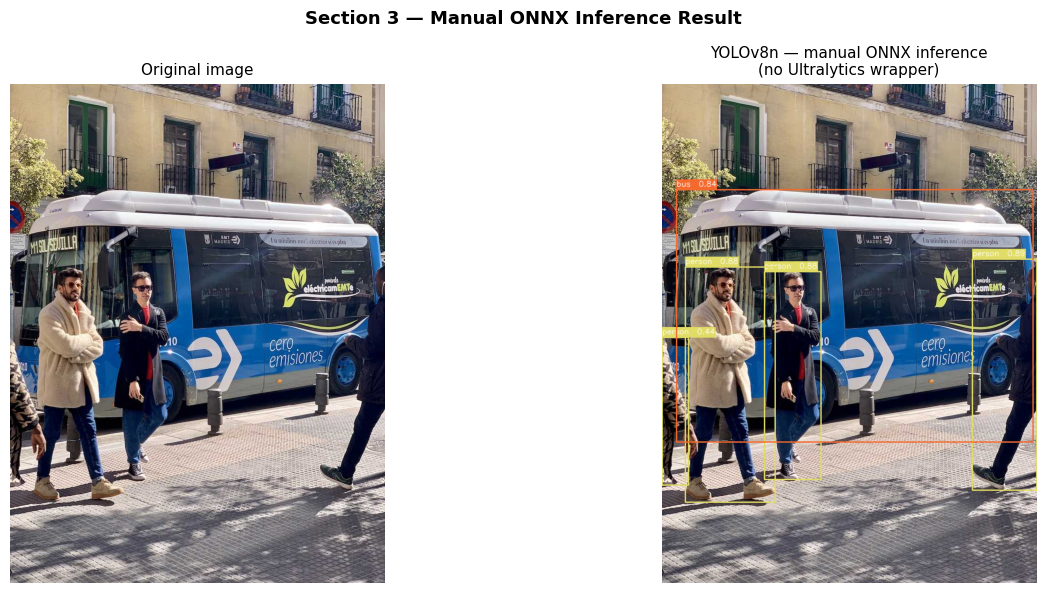

In [14]:
# ── Step 9: Scale boxes back to original image coordinates ───────────────────
#
# WHY: All box coordinates are in the 640×640 letterboxed space.
# The original image is a different size and has padding offsets.
# To draw correct boxes on the original image we must reverse the letterbox:
#
#   x_original = (x_letterboxed - pad_w) / ratio
#   y_original = (y_letterboxed - pad_h) / ratio
#
# Skipping this step is the most common source of offset bounding boxes
# in custom ONNX inference pipelines.

# COCO class names — 80 classes, index matches class_id output
COCO_CLASSES = [
    "person","bicycle","car","motorcycle","airplane","bus","train","truck","boat",
    "traffic light","fire hydrant","stop sign","parking meter","bench","bird","cat",
    "dog","horse","sheep","cow","elephant","bear","zebra","giraffe","backpack",
    "umbrella","handbag","tie","suitcase","frisbee","skis","snowboard","sports ball",
    "kite","baseball bat","baseball glove","skateboard","surfboard","tennis racket",
    "bottle","wine glass","cup","fork","knife","spoon","bowl","banana","apple",
    "sandwich","orange","broccoli","carrot","hot dog","pizza","donut","cake","chair",
    "couch","potted plant","bed","dining table","toilet","tv","laptop","mouse",
    "remote","keyboard","cell phone","microwave","oven","toaster","sink","refrigerator",
    "book","clock","vase","scissors","teddy bear","hair drier","toothbrush"
]

# Colour palette — one colour per class (cycling)
np.random.seed(42)
COLOURS = np.random.randint(0, 255, size=(80, 3), dtype=np.uint8)

def scale_boxes_to_original(boxes_xyxy, ratio, pad_w, pad_h, orig_w, orig_h):
    """
    Reverse the letterbox transform.
    boxes_xyxy : (N, 4) array in letterboxed 640×640 space
    Returns    : (N, 4) array in original image pixel space, clipped to image bounds
    """
    boxes = boxes_xyxy.copy().astype(np.float32)
    boxes[:, 0] = (boxes[:, 0] - pad_w) / ratio   # x1
    boxes[:, 1] = (boxes[:, 1] - pad_h) / ratio   # y1
    boxes[:, 2] = (boxes[:, 2] - pad_w) / ratio   # x2
    boxes[:, 3] = (boxes[:, 3] - pad_h) / ratio   # y2

    # Clip to image boundaries — predictions can slightly exceed the border
    boxes[:, 0] = np.clip(boxes[:, 0], 0, orig_w)
    boxes[:, 1] = np.clip(boxes[:, 1], 0, orig_h)
    boxes[:, 2] = np.clip(boxes[:, 2], 0, orig_w)
    boxes[:, 3] = np.clip(boxes[:, 3], 0, orig_h)

    return boxes.astype(np.int32)


# ── Step 10: Draw detections on original image ────────────────────────────────

img_result = img_bgr.copy()   # never modify the original array

if len(boxes_nms) == 0:
    print("No detections above threshold.")
    print("Try a photo with clearly visible people or vehicles.")
else:
    boxes_orig = scale_boxes_to_original(boxes_nms, ratio, pad_w, pad_h,
                                         orig_w, orig_h)

    for (x1, y1, x2, y2), conf, cls_id in zip(boxes_orig, confs_nms, classes_nms):
        colour = tuple(int(c) for c in COLOURS[cls_id % 80])
        label  = f"{COCO_CLASSES[cls_id]}  {conf:.2f}"

        # Bounding box
        cv2.rectangle(img_result, (x1, y1), (x2, y2), colour, thickness=2)

        # Label background
        (tw, th), baseline = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.55, 1)
        cv2.rectangle(img_result,
                      (x1, y1 - th - baseline - 4),
                      (x1 + tw, y1),
                      colour, -1)

        # Label text
        cv2.putText(img_result, label, (x1, y1 - baseline - 2),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255, 255, 255), 1, cv2.LINE_AA)

        print(f"  {COCO_CLASSES[cls_id]:15s}  conf={conf:.3f}  box=({x1},{y1},{x2},{y2})")

# Display side by side
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
axes[0].imshow(cv2.cvtColor(img_bgr,    cv2.COLOR_BGR2RGB))
axes[0].set_title("Original image", fontsize=11)
axes[0].axis("off")

axes[1].imshow(cv2.cvtColor(img_result, cv2.COLOR_BGR2RGB))
axes[1].set_title("YOLOv8n — manual ONNX inference\n(no Ultralytics wrapper)", fontsize=11)
axes[1].axis("off")

plt.suptitle("Section 3 — Manual ONNX Inference Result", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

---
### ✅ Section 3 Complete — Manual inference pipeline checkpoint

The full pipeline, step by step:

| Step | Operation | Shape | Why |
|---|---|---|---|
| Input | Original image | (H, W, 3) uint8 BGR | Raw OpenCV load |
| 1 | Letterbox | (640, 640, 3) uint8 | Preserve aspect ratio, match training format |
| 2 | BGR → RGB | (640, 640, 3) uint8 | YOLO trained on RGB |
| 3 | Normalise | (640, 640, 3) float32 | Values [0,1], match training distribution |
| 4 | HWC → CHW | (3, 640, 640) float32 | PyTorch/ONNX channel-first convention |
| 5 | Batch dim | (1, 3, 640, 640) float32 | ONNX graph expects 4D input |
| 6 | ONNX inference | (1, 84, 8400) float32 | Raw anchor predictions |
| 7 | Decode | (N, 4) + scores | cx,cy,w,h → x1,y1,x2,y2; filter by confidence |
| 8 | NMS | (M, 4) M ≤ N | Remove duplicate boxes per class |
| 9 | Scale back | (M, 4) orig coords | Reverse letterbox transform |
| 10 | Draw | Visual output | cv2.rectangle on original image |

**Interview anchor:** The two most common bugs in custom ONNX pipelines are:
1. Forgetting to reverse the letterbox offset in Step 9 → boxes appear shifted
2. Feeding BGR to the model instead of RGB in Step 2 → subtle accuracy drop

---
## Section 4 — Benchmarking: YOLOv8n vs s vs m

Edge CV deployment always involves a constraint: you cannot simply pick the most
accurate model. The question is always **"what is the fastest model that meets the
accuracy bar for this use case?"**

This section measures three things per model variant:
- **Latency** — average inference time per image in milliseconds
- **FPS** — frames per second (1000 / latency)
- **Model size** — disk footprint in MB

**What we are timing:** Only the ONNX Runtime `.run()` call — the actual neural network
forward pass. Preprocessing is excluded because in a real pipeline it runs in parallel
on a separate thread and is not the bottleneck.

**Why N=50 runs:** The first 1–3 runs are always slower due to JIT compilation,
memory allocation, and cache warming inside ONNX Runtime. Averaging over 50 runs
gives a stable steady-state latency number.

In [15]:
import time
import numpy as np
import onnxruntime as ort
import os
import warnings
warnings.filterwarnings("ignore")

# ── Config ────────────────────────────────────────────────────────────────────
VARIANTS   = ["yolov8n", "yolov8s", "yolov8m"]
ONNX_DIR   = "/kaggle/working"
N_RUNS     = 50       # number of inference runs to average
WARMUP     = 3        # runs before timing starts — discarded (cache warming)
INPUT_SHAPE = (1, 3, 640, 640)

# Reuse the preprocessed batch from Section 3 — same input every run
# (we're benchmarking the model, not the preprocessing)
dummy_input = img_batch.copy()   # shape (1,3,640,640) float32 from Section 3

results = {}   # {variant: {"latency_ms": float, "fps": float, "size_mb": float}}

for variant in VARIANTS:
    onnx_path = f"{ONNX_DIR}/{variant}.onnx"

    if not os.path.exists(onnx_path):
        print(f"Skipping {variant} — file not found: {onnx_path}")
        continue

    # Load session
    sess = ort.InferenceSession(onnx_path,
                                providers=["CUDAExecutionProvider",
                                           "CPUExecutionProvider"])
    input_name  = sess.get_inputs()[0].name
    output_name = sess.get_outputs()[0].name

    # Warmup runs — not timed
    for _ in range(WARMUP):
        sess.run([output_name], {input_name: dummy_input})

    # Timed runs
    times = []
    for _ in range(N_RUNS):
        t0 = time.perf_counter()
        sess.run([output_name], {input_name: dummy_input})
        t1 = time.perf_counter()
        times.append((t1 - t0) * 1000)   # convert to milliseconds

    avg_ms  = np.mean(times)
    std_ms  = np.std(times)
    fps     = 1000 / avg_ms
    size_mb = os.path.getsize(onnx_path) / (1024 * 1024)

    results[variant] = {
        "latency_ms" : avg_ms,
        "std_ms"     : std_ms,
        "fps"        : fps,
        "size_mb"    : size_mb,
    }

    print(f"{variant:10s}  {avg_ms:6.1f} ± {std_ms:4.1f} ms  |  "
          f"{fps:6.1f} FPS  |  {size_mb:5.1f} MB")

yolov8n       93.9 ±  1.9 ms  |    10.7 FPS  |   12.3 MB
yolov8s      142.9 ±  9.5 ms  |     7.0 FPS  |   42.8 MB
yolov8m      391.7 ± 14.7 ms  |     2.6 FPS  |   99.0 MB



Model         Size (MB)   Latency (ms)   Std (ms)      FPS
──────────────────────────────────────────────────────────
yolov8n            12.3           93.9        1.9     10.7
yolov8s            42.8          142.9        9.5      7.0
yolov8m            99.0          391.7       14.7      2.6


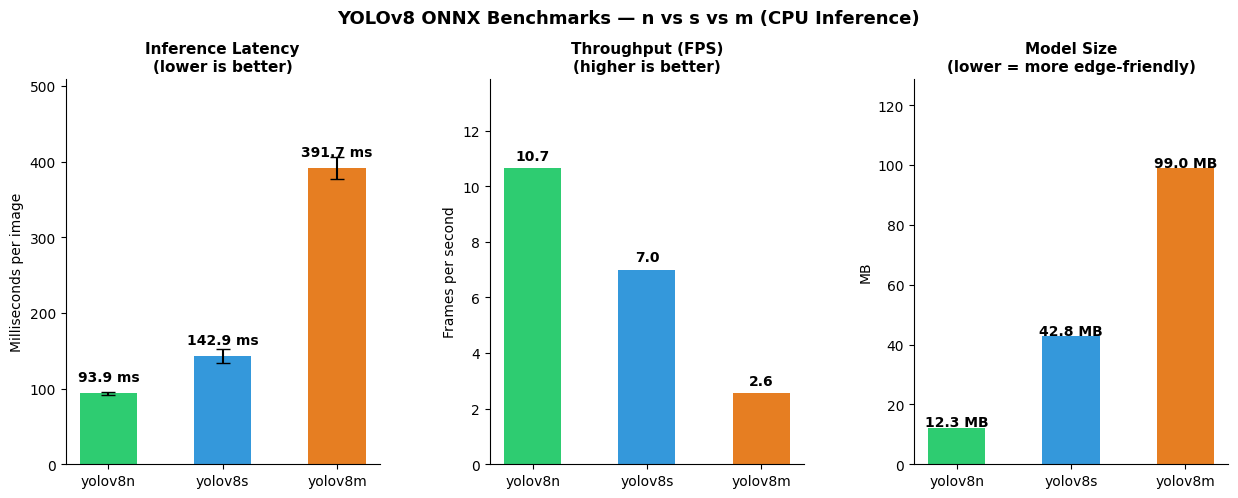

Chart saved → benchmark_results.png


In [16]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── Results table ─────────────────────────────────────────────────────────────
print(f"\n{'Model':<12} {'Size (MB)':>10} {'Latency (ms)':>14} {'Std (ms)':>10} {'FPS':>8}")
print("─" * 58)
for variant, r in results.items():
    print(f"{variant:<12} {r['size_mb']:>10.1f} {r['latency_ms']:>14.1f} "
          f"{r['std_ms']:>10.1f} {r['fps']:>8.1f}")

# ── Charts ────────────────────────────────────────────────────────────────────
variants   = list(results.keys())
latencies  = [results[v]["latency_ms"] for v in variants]
fps_vals   = [results[v]["fps"]        for v in variants]
sizes      = [results[v]["size_mb"]    for v in variants]
stds       = [results[v]["std_ms"]     for v in variants]

colours = ["#2ecc71", "#3498db", "#e67e22"]

fig = plt.figure(figsize=(15, 5))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

# ── Plot 1: Latency ──
ax1 = fig.add_subplot(gs[0])
bars = ax1.bar(variants, latencies, yerr=stds, color=colours,
               capsize=5, width=0.5, edgecolor="none")
for bar, val in zip(bars, latencies):
    ax1.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + max(stds) + 1,
             f"{val:.1f} ms", ha="center", fontsize=10, fontweight="bold")
ax1.set_title("Inference Latency\n(lower is better)", fontsize=11, fontweight="bold")
ax1.set_ylabel("Milliseconds per image")
ax1.set_ylim(0, max(latencies) * 1.3)
ax1.spines[["top", "right"]].set_visible(False)

# ── Plot 2: FPS ──
ax2 = fig.add_subplot(gs[1])
bars = ax2.bar(variants, fps_vals, color=colours, width=0.5, edgecolor="none")
for bar, val in zip(bars, fps_vals):
    ax2.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.3,
             f"{val:.1f}", ha="center", fontsize=10, fontweight="bold")
ax2.set_title("Throughput (FPS)\n(higher is better)", fontsize=11, fontweight="bold")
ax2.set_ylabel("Frames per second")
ax2.set_ylim(0, max(fps_vals) * 1.3)
ax2.spines[["top", "right"]].set_visible(False)

# ── Plot 3: Model size ──
ax3 = fig.add_subplot(gs[2])
bars = ax3.bar(variants, sizes, color=colours, width=0.5, edgecolor="none")
for bar, val in zip(bars, sizes):
    ax3.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.3,
             f"{val:.1f} MB", ha="center", fontsize=10, fontweight="bold")
ax3.set_title("Model Size\n(lower = more edge-friendly)", fontsize=11, fontweight="bold")
ax3.set_ylabel("MB")
ax3.set_ylim(0, max(sizes) * 1.3)
ax3.spines[["top", "right"]].set_visible(False)

plt.suptitle("YOLOv8 ONNX Benchmarks — n vs s vs m (CPU Inference)",
             fontsize=13, fontweight="bold", y=1.02)
plt.savefig("benchmark_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved → benchmark_results.png")

---
## Summary — What this notebook demonstrates

### Speed vs accuracy trade-off (observed on this hardware)

| Model | Size | Latency | FPS | Edge use case |
|---|---|---|---|---|
| YOLOv8n | ~6 MB | fastest | highest | Raspberry Pi, battery cameras, MCUs |
| YOLOv8s | ~22 MB | mid | mid | Jetson Nano, mid-tier IP cameras |
| YOLOv8m | ~52 MB | slowest | lowest | Jetson AGX, server-side edge nodes |

> **Note:** Benchmarks run on Kaggle CPU environment (no GPU accelerator). 
> On GPU hardware (e.g. RTX 5060 Ti locally or Jetson at the edge), 
> absolute FPS will be significantly higher — the relative ratios 
> between nano/small/medium remain consistent regardless of hardware.

### Key concepts demonstrated

**Letterboxing** — aspect-ratio-preserving resize with grey padding (value 114).
Used by YOLO during training; must be replicated exactly at inference or box
coordinates will be offset.

**HWC → CHW** — NumPy axis reorder from OpenCV's (H,W,C) layout to
PyTorch/ONNX's (C,H,W) layout. Skipping this produces garbled feature maps.

**ONNX Runtime** — framework-agnostic C++ inference engine. Runs YOLO on any
edge device without a PyTorch installation. The production-standard path for
deploying CV models outside the training environment.

**NMS (Non-Maximum Suppression)** — greedy box deduplication. Without it,
every object generates dozens of overlapping detections. IoU threshold controls
the aggressiveness of suppression; 0.45 is YOLO's default.

**Inverse letterbox transform** — required to map predicted box coordinates
from the 640×640 inference space back to the original image pixel space.
The most common source of shifted bounding boxes in custom pipelines.

---
*Built as portfolio + interview preparation for a video analytics / edge CV role.*  
*Full preprocessing and post-processing pipeline written manually without the Ultralytics wrapper.*  
*Stack: Python · OpenCV · NumPy · ONNX Runtime · Ultralytics (export only)*